# EDA: Evaluation Corpus (5,005 Letter Texts)

**Purpose**: Explore the unified evaluation corpus for LLM baseline predictions

**Data**: 
- Word-level: `v_1/data/evaluation_corpora/unified_3groups_akkadian_letters.parquet`
- Text-level: `v_1/data/evaluation_corpora/texts_for_evaluation.parquet`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [2]:
# Load word-level data
word_df = pd.read_parquet('../data/evaluation_corpora/unified_3groups_akkadian_letters.parquet')
print(f"Word-level data: {len(word_df):,} rows")
print(f"Unique texts: {word_df['fragment_id'].nunique():,}")

# Load text-level data
text_df = pd.read_parquet('../data/evaluation_corpora/texts_for_evaluation.parquet')
print(f"\nText-level data: {len(text_df):,} rows")

Word-level data: 290,649 rows
Unique texts: 5,005

Text-level data: 4,976 rows


## 2. Word-Level Data Overview

In [3]:
# Show columns
print("Columns:")
print(list(word_df.columns))

Columns:
['fragment_id', 'fragment_line_num', 'index_in_line', 'word_language', 'domain', 'place_discovery', 'place_composition', 'value', 'clean_value', 'lemma', 'temporal_group', 'period', 'period_approx', 'corpus_source', 'domain_original', 'domain_standard', 'domain_finegrained']


In [4]:
# Data types and info
word_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290649 entries, 0 to 290648
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   fragment_id         290649 non-null  object
 1   fragment_line_num   290649 non-null  object
 2   index_in_line       290649 non-null  int64 
 3   word_language       290649 non-null  object
 4   domain              290649 non-null  object
 5   place_discovery     290649 non-null  object
 6   place_composition   290649 non-null  object
 7   value               290649 non-null  object
 8   clean_value         290649 non-null  object
 9   lemma               290649 non-null  object
 10  temporal_group      290649 non-null  object
 11  period              290649 non-null  object
 12  period_approx       290649 non-null  object
 13  corpus_source       290649 non-null  object
 14  domain_original     290649 non-null  object
 15  domain_standard     290649 non-null  object
 16  do

In [5]:
# Sample rows
print("Sample word-level data:")
word_df.head(20)

Sample word-level data:


,fragment_id,fragment_line_num,index_in_line,word_language,domain,place_discovery,place_composition,value,clean_value,lemma,temporal_group,period,period_approx,corpus_source,domain_original,domain_standard,domain_finegrained
0,ARM 10 33,1,0,akk,lettre politique,Mari,Ilan-ṣura,a-na,a-na,ana,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),archibab,lettre politique,Letter,Political Letter
1,ARM 10 33,1,1,akk,lettre politique,Mari,Ilan-ṣura,be-lí,be-li2,bêlum,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),archibab,lettre politique,Letter,Political Letter
2,ARM 10 33,1,2,akk,lettre politique,Mari,Ilan-ṣura,ù,u3,u,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),archibab,lettre politique,Letter,Political Letter
3,ARM 10 33,1,3,akk,lettre politique,Mari,Ilan-ṣura,ka-ka-bi,ka-ka-bi,kakkabum,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),archibab,lettre politique,Letter,Political Letter
4,ARM 10 33,2,0,akk,lettre politique,Mari,Ilan-ṣura,qí-bí-ma,qi2-bi2-ma,qabûm,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),archibab,lettre politique,Letter,Political Letter
5,ARM 10 33,3,0,akk,lettre politique,Mari,Ilan-ṣura,um-ma,um-ma,umma,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),archibab,lettre politique,Letter,Political Letter
6,ARM 10 33,3,1,akk,lettre politique,Mari,Ilan-ṣura,(munus)-ki-ru-ú-ma,munus-ki-ru-u2-ma,Kirum,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),archibab,lettre politique,Letter,Political Letter
7,ARM 10 33,4,0,akk,lettre politique,Mari,Ilan-ṣura,DUMU-MUNUS-ka-a-ma,DUMU-MUNUS-ka-a-ma,mârtum,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),archibab,lettre politique,Letter,Political Letter
8,ARM 10 33,5,0,akk,lettre politique,Mari,Ilan-ṣura,ik-ta-ru,ik-ta-ru,karûm,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),archibab,lettre politique,Letter,Political Letter
9,ARM 10 33,5,1,akk,lettre politique,Mari,Ilan-ṣura,na-pá-aš-ti,na-pa2-aš-ti,napištum,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),archibab,lettre politique,Letter,Political Letter


## 3. Text-Level Data Overview

In [6]:
# Show columns
print("Columns:")
print(list(text_df.columns))

Columns:
['fragment_id', 'full_text', 'word_count', 'line_count', 'char_count', 'temporal_group', 'period', 'period_approx', 'domain_standard', 'domain_finegrained', 'place_discovery', 'corpus_source']


In [7]:
# Data types and info
text_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4976 entries, 0 to 4975
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   fragment_id         4976 non-null   object
 1   full_text           4976 non-null   object
 2   word_count          4976 non-null   int64 
 3   line_count          4976 non-null   int64 
 4   char_count          4976 non-null   int64 
 5   temporal_group      4976 non-null   object
 6   period              4976 non-null   object
 7   period_approx       4976 non-null   object
 8   domain_standard     4976 non-null   object
 9   domain_finegrained  4976 non-null   object
 10  place_discovery     4976 non-null   object
 11  corpus_source       4976 non-null   object
dtypes: int64(3), object(9)
memory usage: 466.6+ KB


In [8]:
# Basic statistics
text_df.describe()

,word_count,line_count,char_count
count,4976.000000,4976.000000,4976.000000
mean,58.108521,19.881029,460.616359
std,50.484832,11.403214,409.702586
min,1.000000,1.000000,6.000000
25%,26.000000,11.000000,212.750000
50%,44.500000,18.000000,354.000000
75%,76.000000,26.000000,589.250000
max,761.000000,146.000000,6776.000000


In [9]:
# Sample texts (showing first 500 chars of full_text)
sample = text_df[['fragment_id', 'full_text', 'word_count', 'line_count', 
                   'temporal_group', 'period', 'domain_standard', 'corpus_source']].head(10)
sample['full_text_preview'] = sample['full_text'].str[:200] + '...'
sample.drop('full_text', axis=1)

,fragment_id,word_count,line_count,temporal_group,period,domain_standard,corpus_source,full_text_preview
0,ARM 10 33,83,34,Group 1,Old Babylonian,Letter,archibab,a-na be-li2 u3 ka-ka-bi\na-nu-um-ma I-ia-ri-im-d-da-gan\nka-la-šu a-na be-li2\nbu-ub\nu2 a-na-ku...
1,ARM 10 35,39,19,Group 1,Old Babylonian,Letter,archibab,a-na be-li2-ia u3 a-bi-ia\nša-ni-tam aš-šum be-li2\nu3 aš-šum-mi-ma\nI-di3-im-ri-ha-am-mu\ni-du-...
2,ARM 10 5,137,40,Group 1,Old Babylonian,Letter,archibab,a-na be-li2-ia qi2\ni-na bi-ri-šu-nu ni-iš DINGIR-MEŠ iz3-ku-ru-ma\nu3 pu-hu-ur qa-qa-da-ti-šu-n...
3,ARM 27 139,20,11,Group 1,Old Babylonian,Letter,archibab,a-na be-li2-ia\na-na ṣe-er be-li2-ia\nu2-ša-bi-lam\nqi2-bi2-ma\num-ma zi-im-ri-d-IŠKUR\nIR3-ka-a...
4,ARM 27 145,94,29,Group 1,Old Babylonian,Letter,archibab,a-na be-li2-ia qi2-bi2-ma\nLU2-KUR2 iš-šu-ma ge-er-ri ka-ak-ku-la-tim-ki\niṣ-ba-tu i-na pa-ni-ti...
5,ARM 27 148,76,27,Group 1,Old Babylonian,Letter,archibab,a-na be-li2-ia\nša it-ti ṣa-ab LU2 ELAM-MA-ki\nwa-aš-bu u2-še-ṣi2-ma\nṣa-ba-am LU2 ELAM-MA-ma\nu...
6,ARM 27 151,761,105,Group 1,Old Babylonian,Letter,archibab,be-li2-ia qi2-bi2-ma um-ma zi-im-ri-d-IŠKUR IR3-ka-a-ma\nka-ni-ik ki-ma-a DUB-SAR MAR-TU qi2-pu-...
7,ARM 27 154,110,34,Group 1,Old Babylonian,Letter,archibab,a-na be-li2-ia\nu3 ṣa-bu-um ša ia-si-im-AN li-it-ta-al-kam\nṭe4-ma-am ša-a-tu IGI as3-IŠKUR\nni-...
8,ARM 27 157,56,20,Group 1,Old Babylonian,Letter,archibab,be-li2-ia\nṣa-ab-tam-ma ar-hi-iš a-la-kam\nan-ni-tam be-li2 iš-pu-ra\nna-an-na a-lum la-ar-sa\ni...
9,ARM 27 160,37,16,Group 1,Old Babylonian,Letter,archibab,a-na ha-lu-u2\nlu-u2 ka-a-ia-an\na-nu-um-ma ṭup-pa-tim a-na ṣe-er LUGAL\nu2-ša-bi-lam\na-na ṭe4-...


## 4. Distribution by Temporal Group & Period

In [10]:
# Count by temporal group
print("Distribution by Temporal Group:")
print(text_df['temporal_group'].value_counts().sort_index())
print(f"\nTotal: {len(text_df):,} texts")

Distribution by Temporal Group:
temporal_group
Group 1    1497
Group 2    2435
Group 3    1044
Name: count, dtype: int64

Total: 4,976 texts


In [11]:
# Count by period
print("Distribution by Period:")
print(text_df['period'].value_counts())

Distribution by Period:
period
Neo-Assyrian       2435
Old Babylonian     1497
Late Babylonian    1044
Name: count, dtype: int64


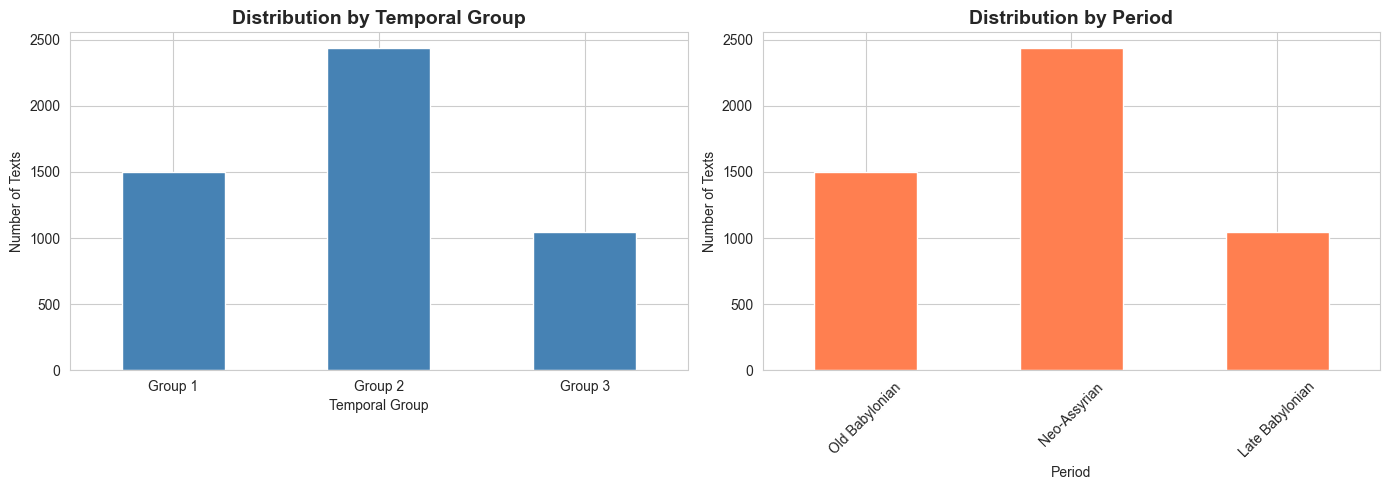

In [12]:
# Visualize temporal distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By temporal group
text_df['temporal_group'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution by Temporal Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Temporal Group')
axes[0].set_ylabel('Number of Texts')
axes[0].tick_params(axis='x', rotation=0)

# By period
period_order = ['Old Babylonian', 'Neo-Assyrian', 'Late Babylonian']
text_df['period'].value_counts().reindex(period_order).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Distribution by Period', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Period')
axes[1].set_ylabel('Number of Texts')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Distribution by Corpus Source

In [13]:
# Count by corpus source
print("Distribution by Corpus Source:")
print(text_df['corpus_source'].value_counts())

Distribution by Corpus Source:
corpus_source
oracc       2435
archibab    1497
lbl         1044
Name: count, dtype: int64


In [14]:
# Cross-tab: corpus source vs period
pd.crosstab(text_df['corpus_source'], text_df['period'], margins=True)

period,Late Babylonian,Neo-Assyrian,Old Babylonian,All
corpus_source,,,,
archibab,0,0,1497,1497
lbl,1044,0,0,1044
oracc,0,2435,0,2435
All,1044,2435,1497,4976


## 6. Domain Analysis

In [15]:
# Domain standard distribution
print("Distribution by Domain (Standard):")
print(text_df['domain_standard'].value_counts())

Distribution by Domain (Standard):
domain_standard
Letter    4976
Name: count, dtype: int64


In [16]:
# Domain finegrained distribution
print("Distribution by Domain (Fine-grained):")
print(text_df['domain_finegrained'].value_counts())

Distribution by Domain (Fine-grained):
domain_finegrained
Neo-Assyrian Letter       2435
Administrative Letter     1157
Late Babylonian Letter    1044
Political Letter           196
Private Letter             126
Diplomatic Letter           18
Name: count, dtype: int64


In [17]:
# Domain by period
pd.crosstab(text_df['period'], text_df['domain_finegrained'], margins=True)

domain_finegrained,Administrative Letter,Diplomatic Letter,Late Babylonian Letter,Neo-Assyrian Letter,Political Letter,Private Letter,All
period,,,,,,,
Late Babylonian,0,0,1044,0,0,0,1044
Neo-Assyrian,0,0,0,2435,0,0,2435
Old Babylonian,1157,18,0,0,196,126,1497
All,1157,18,1044,2435,196,126,4976


## 7. Place of Discovery

In [18]:
# Top places by temporal group
print("Top Places of Discovery by Temporal Group:\n")
for group in sorted(text_df['temporal_group'].unique()):
    print(f"{group}:")
    places = text_df[text_df['temporal_group'] == group]['place_discovery'].value_counts().head(10)
    print(places)
    print()

Top Places of Discovery by Temporal Group:

Group 1:
place_discovery
Mari               907
Larsa              276
Qaṭṭara             72
Lagaš               48
Kisurra             43
Ešnunna             34
Šaduppum            31
Šušarra             27
Sippar-Yahrurum     19
Sippar-Amnanum      16
Name: count, dtype: int64

Group 2:
place_discovery
Kuyunjik (Nineveh)          2183
Nimrud (Kalhu)               247
Qalat Sherqat (Assur)          3
Khorsabad (Dur-Šarrukin)       2
Name: count, dtype: int64

Group 3:
place_discovery
URUK                  486
BABYLON und SIPPAR    317
DIVERSE               186
BORSIPPA               32
NIPPUR                 13
New URUK LETTERS        7
SONSTIGE                3
Name: count, dtype: int64



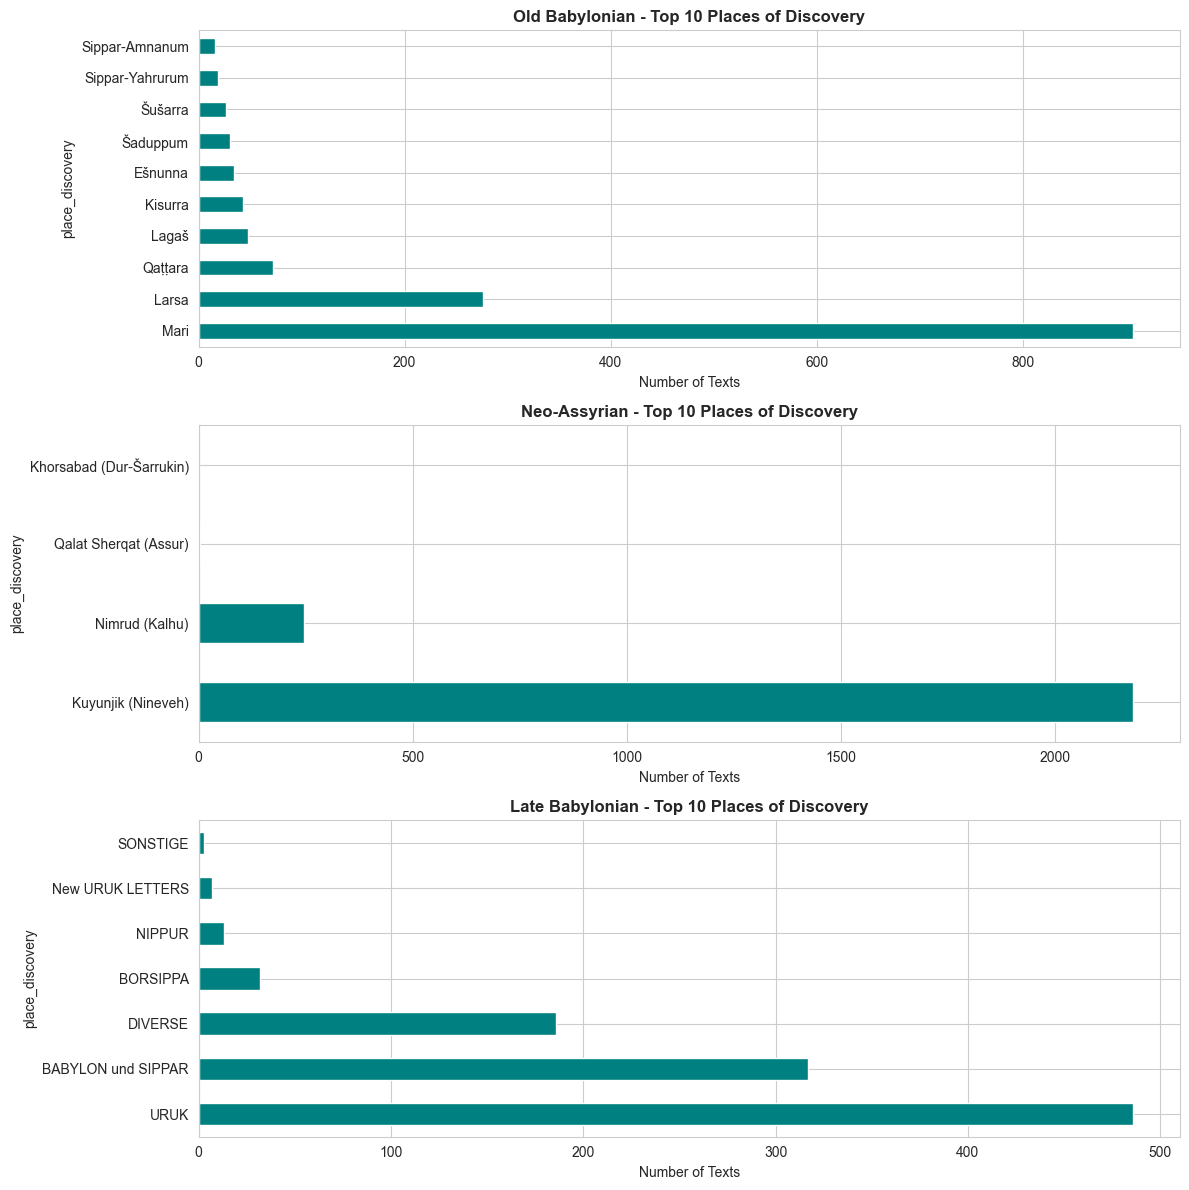

In [19]:
# Visualize top places per period
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

periods = ['Old Babylonian', 'Neo-Assyrian', 'Late Babylonian']
for i, period in enumerate(periods):
    subset = text_df[text_df['period'] == period]
    top_places = subset['place_discovery'].value_counts().head(10)
    top_places.plot(kind='barh', ax=axes[i], color='teal')
    axes[i].set_title(f'{period} - Top 10 Places of Discovery', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Number of Texts')
    
plt.tight_layout()
plt.show()

## 8. Text Length Statistics

In [20]:
# Overall statistics
print("Text Length Statistics:")
print(f"\nWord Count:")
print(text_df['word_count'].describe())
print(f"\nLine Count:")
print(text_df['line_count'].describe())
print(f"\nCharacter Count:")
print(text_df['char_count'].describe())

Text Length Statistics:

Word Count:
count    4976.000000
mean       58.108521
std        50.484832
min         1.000000
25%        26.000000
50%        44.500000
75%        76.000000
max       761.000000
Name: word_count, dtype: float64

Line Count:
count    4976.000000
mean       19.881029
std        11.403214
min         1.000000
25%        11.000000
50%        18.000000
75%        26.000000
max       146.000000
Name: line_count, dtype: float64

Character Count:
count    4976.000000
mean      460.616359
std       409.702586
min         6.000000
25%       212.750000
50%       354.000000
75%       589.250000
max      6776.000000
Name: char_count, dtype: float64


In [21]:
# Length statistics by temporal group
print("Average Text Lengths by Temporal Group:\n")
text_df.groupby('temporal_group')[['word_count', 'line_count', 'char_count']].mean().round(1)

Average Text Lengths by Temporal Group:



,word_count,line_count,char_count
temporal_group,,,
Group 1,52.5,19.8,465.1
Group 2,56.0,18.8,441.1
Group 3,71.0,22.4,499.6


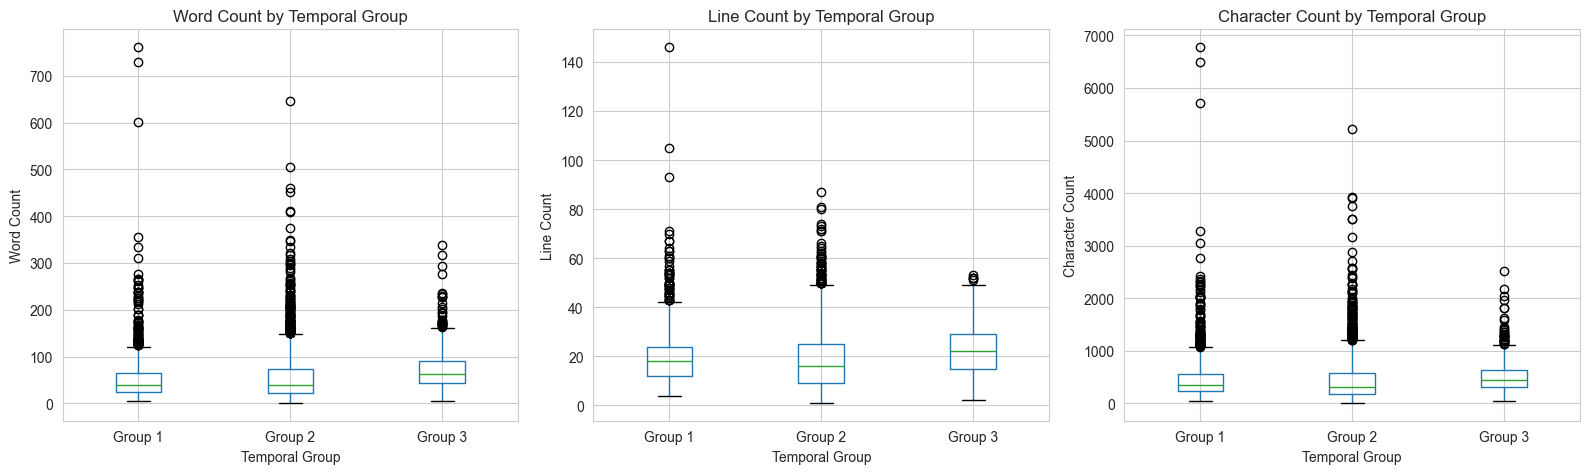

In [22]:
# Visualize text length distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Word count distribution
text_df.boxplot(column='word_count', by='temporal_group', ax=axes[0])
axes[0].set_title('Word Count by Temporal Group')
axes[0].set_xlabel('Temporal Group')
axes[0].set_ylabel('Word Count')
axes[0].get_figure().suptitle('')  # Remove auto title

# Line count distribution
text_df.boxplot(column='line_count', by='temporal_group', ax=axes[1])
axes[1].set_title('Line Count by Temporal Group')
axes[1].set_xlabel('Temporal Group')
axes[1].set_ylabel('Line Count')
axes[1].get_figure().suptitle('')

# Character count distribution
text_df.boxplot(column='char_count', by='temporal_group', ax=axes[2])
axes[2].set_title('Character Count by Temporal Group')
axes[2].set_xlabel('Temporal Group')
axes[2].set_ylabel('Character Count')
axes[2].get_figure().suptitle('')

plt.tight_layout()
plt.show()

## 9. Sample Texts by Period

In [23]:
# Show one example text from each period
for period in ['Old Babylonian', 'Neo-Assyrian', 'Late Babylonian']:
    print("=" * 80)
    print(f"SAMPLE TEXT: {period}")
    print("=" * 80)
    
    sample = text_df[text_df['period'] == period].iloc[0]
    
    print(f"Fragment ID: {sample['fragment_id']}")
    print(f"Temporal Group: {sample['temporal_group']}")
    print(f"Period: {sample['period']} ({sample.get('period_approx', 'N/A')})")
    print(f"Domain: {sample['domain_standard']} / {sample.get('domain_finegrained', 'N/A')}")
    print(f"Place: {sample['place_discovery']}")
    print(f"Source: {sample['corpus_source']}")
    print(f"Length: {sample['word_count']} words, {sample['line_count']} lines, {sample['char_count']} chars")
    print(f"\nText (first 500 chars):")
    print("-" * 80)
    print(sample['full_text'][:500])
    print("...")
    print()

SAMPLE TEXT: Old Babylonian
Fragment ID: ARM 10 33
Temporal Group: Group 1
Period: Old Babylonian (2nd millennium BCE (~1800 BCE))
Domain: Letter / Political Letter
Place: Mari
Source: archibab
Length: 83 words, 34 lines, 710 chars

Text (first 500 chars):
--------------------------------------------------------------------------------
a-na be-li2 u3 ka-ka-bi
a-nu-um-ma I-ia-ri-im-d-da-gan
ka-la-šu a-na be-li2
bu-ub
u2 a-na-ku
ar LUGAL
at-ta ma-an-nu
u2 GEME2 mu-uš-ke-ni-im
a-wa-tim
tim ik-ta-ru na-pa2-aš-ti
bi li-iš-pu-ra-am-ma
qi2-bi2-ma
ma-ri-ki li-it-ru-ni-in-ni
ib-bi E2-ta-am
ta-am u2-ul ha-aš-ha-ku
ma a-ia-ši lu ba-al-ṭa3-ta
si2-ik-ti
ma-ha-ar LUGAL-MEŠ
ib-tu-uq um-ma šu-ma
at-la-ki a-na E2 a-bi-ki
iš-tu pa-ni a-ša-ti-ia
a-mu-ur
um-ma munus-ki-ru-u2-ma
ša-ni-tam a-we-el-tam ša a-na be-li2-ia
aq-bu-u2 i-na qa-ti-ia
i-ki-i
...

SAMPLE TEXT: Neo-Assyrian
Fragment ID: P224378
Temporal Group: Group 2
Period: Neo-Assyrian (9-7 cent BCE)
Domain: Letter / Neo-Assyrian Letter
Place: Nimru

## 10. Data Quality Checks

In [24]:
# Check for missing values
print("Missing values:")
print(text_df.isnull().sum())

Missing values:
fragment_id           0
full_text             0
word_count            0
line_count            0
char_count            0
temporal_group        0
period                0
period_approx         0
domain_standard       0
domain_finegrained    0
place_discovery       0
corpus_source         0
dtype: int64


In [25]:
# Check for empty texts
empty_texts = text_df[text_df['full_text'].str.strip() == '']
print(f"Empty texts: {len(empty_texts)}")

zero_word = text_df[text_df['word_count'] == 0]
print(f"Zero word count: {len(zero_word)}")

Empty texts: 0
Zero word count: 0


In [26]:
# Check temporal group consistency
print("Temporal Group vs Period consistency check:")
pd.crosstab(text_df['temporal_group'], text_df['period'])

Temporal Group vs Period consistency check:


period,Late Babylonian,Neo-Assyrian,Old Babylonian
temporal_group,,,
Group 1,0,0,1497
Group 2,0,2435,0
Group 3,1044,0,0


In [27]:
# Check corpus source consistency
print("Corpus Source vs Period consistency check:")
pd.crosstab(text_df['corpus_source'], text_df['period'])

Corpus Source vs Period consistency check:


period,Late Babylonian,Neo-Assyrian,Old Babylonian
corpus_source,,,
archibab,0,0,1497
lbl,1044,0,0
oracc,0,2435,0


## 11. Summary Statistics for LLM Evaluation

In [28]:
# Load token statistics if available
import json

token_stats_path = Path('../data/evaluation_corpora/texts_token_stats.json')
if token_stats_path.exists():
    with open(token_stats_path, 'r') as f:
        token_stats = json.load(f)
    
    print("Token Statistics for LLM API Calls:")
    print("=" * 50)
    print(f"Total texts: {token_stats['total_texts']:,}")
    print(f"Total characters: {token_stats['total_chars']:,}")
    print(f"Estimated tokens (text): {token_stats['estimated_tokens']:,}")
    print(f"Average tokens per text: {token_stats['avg_tokens_per_text']:.1f}")
    print(f"P50 tokens per text: {token_stats['p50_tokens_per_text']:.1f}")
    print(f"P95 tokens per text: {token_stats['p95_tokens_per_text']:.1f}")
    print(f"Max tokens per text: {token_stats['max_tokens_per_text']:,}")
    print(f"Prompt template tokens: {token_stats['prompt_template_tokens']}")
    print(f"Estimated total input tokens: {token_stats['estimated_total_input_tokens']:,}")
else:
    print("Token statistics file not found. Run 01_prepare_texts.py first.")

Token Statistics for LLM API Calls:
Total texts: 5,005
Total characters: 2,305,102
Estimated tokens (text): 574,402
Average tokens per text: 114.8
P50 tokens per text: 88.0
P95 tokens per text: 286.8
Max tokens per text: 1,694
Prompt template tokens: 500
Estimated total input tokens: 3,076,902


## 12. Export Sample for Manual Inspection

In [29]:
# Create a sample of 10 texts per period for manual review
sample_export = pd.concat([
    text_df[text_df['period'] == 'Old Babylonian'].sample(10, random_state=42),
    text_df[text_df['period'] == 'Neo-Assyrian'].sample(10, random_state=42),
    text_df[text_df['period'] == 'Late Babylonian'].sample(10, random_state=42)
])

# Select relevant columns
sample_export = sample_export[['fragment_id', 'full_text', 'word_count', 'line_count', 
                                 'temporal_group', 'period', 'period_approx',
                                 'domain_standard', 'domain_finegrained', 
                                 'place_discovery', 'corpus_source']]

print(f"Sample export: {len(sample_export)} texts (10 per period)")
sample_export.head()

Sample export: 30 texts (10 per period)


,fragment_id,full_text,word_count,line_count,temporal_group,period,period_approx,domain_standard,domain_finegrained,place_discovery,corpus_source
1033,ARM 14 100,a-na be-li2-ia\nki-i u3 šum-ma\nma-am-ma-an it\naš-šum SAG-SA2-šu-nu\nan-ni-tam la an-ni-tam be-...,30,14,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),Letter,Administrative Letter,Mari,archibab
1304,ARM 3 12,be-li2-ia\nLU2-MEŠ su-tu bi-ri A-ŠA3 i-na pu-ra-tim\ne-le-nu-um ter-qa-ki sa-ak-nu-ma\nka-a-ia-a...,85,26,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),Letter,Political Letter,Mari,archibab
1389,ARM 13 63,a-na i-di2-ia-tim\nU4\nqi2-bi2-ma\num-ma d-NU-MUŠ-DA-na-ah-ra-ri\ni-na giš-MA2-TUR\nša a-bu-wa-q...,16,10,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),Letter,Administrative Letter,Mari,archibab
1488,ARM 26/2 340,a-na šu-nu-uh-ra-ha-lu-u2\nku-ma ki-a-am\nšu-nu-ti um-ma-a\nša-ni ki-a-am ta-aq-be2-em\num-ma ta...,63,24,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),Letter,Private Letter,Mari,archibab
788,ARM 27 101,a-na be-li2-ia qi2-bi2-ma\nša a-na ṣe-er be-li2-ia u2-ša-bi-lam\nmi-lu-um ša ha-bu-ur2 am-ma-tim...,129,34,Group 1,Old Babylonian,2nd millennium BCE (~1800 BCE),Letter,Administrative Letter,Mari,archibab


In [30]:
# Optionally save to CSV for external review
# sample_export.to_csv('../data/evaluation_corpora/sample_texts_for_review.csv', index=False)
# print("Sample exported to: sample_texts_for_review.csv")

---

## Summary

This notebook provides an overview of the **5,005 Akkadian letter texts** prepared for LLM baseline evaluation:

- **Three temporal groups**: Old Babylonian (1,526), Neo-Assyrian (2,435), Late Babylonian (1,044)
- **All texts are letters** (genre consistency per Nathan's guidance)
- **Clear geographic and temporal separation**
- **Ready for Phase 2 LLM predictions**

Next steps:
1. Set OpenRouter API key: `export OPENROUTER_API_KEY="your-key"`
2. Run predictions: `python v_1/src/evaluation/02_llm_baseline.py --model gpt-oss-20b`
3. Aggregate results: `python v_1/src/evaluation/03_aggregate_results.py`
4. Evaluate: `python v_1/src/evaluation/04_evaluate_baseline.py`

## 13. Data Cleanup: Fix Domain Labels

Fix domain labels to use consistent "Unknown" values:
- Replace `nan` in `domain_finegrained` with "Unknown"
- Replace "Other" in `domain_standard` with "Unknown"

In [31]:
# Check current distribution BEFORE cleanup
print("=" * 80)
print("BEFORE CLEANUP")
print("=" * 80)
print(f"Total texts: {len(text_df):,}")
print("\nDomain Standard:")
print(text_df['domain_standard'].value_counts(dropna=False))
print("\nDomain Finegrained:")
print(text_df['domain_finegrained'].value_counts(dropna=False))

# Fix 1: Replace string "nan" in domain_finegrained with "Unknown"
print("\n" + "=" * 80)
print("Fixing domain_finegrained: 'nan' (string) and NaN → 'Unknown'")
print("=" * 80)

# Handle both actual NaN and string "nan"
nan_count_actual = text_df['domain_finegrained'].isna().sum()
nan_count_string = (text_df['domain_finegrained'] == 'nan').sum()
print(f"Found {nan_count_actual} actual NaN values")
print(f"Found {nan_count_string} string 'nan' values")

# Fix both types
text_df['domain_finegrained'] = text_df['domain_finegrained'].fillna('Unknown')
text_df.loc[text_df['domain_finegrained'] == 'nan', 'domain_finegrained'] = 'Unknown'

print(f"✓ Replaced {nan_count_actual + nan_count_string} values with 'Unknown'")

# Fix 2: Replace "Other" in domain_standard with "Unknown"
print("\n" + "=" * 80)
print("Fixing domain_standard: 'Other' → 'Unknown'")
print("=" * 80)
other_count = (text_df['domain_standard'] == 'Other').sum()
print(f"Found {other_count} 'Other' values")
text_df['domain_standard'] = text_df['domain_standard'].replace('Other', 'Unknown')
print(f"✓ Replaced {other_count} 'Other' values with 'Unknown'")

# Check intermediate state
print("\n" + "=" * 80)
print("AFTER LABEL FIXES (before dropping Unknown)")
print("=" * 80)
print(f"Total texts: {len(text_df):,}")
print("\nDomain Standard:")
print(text_df['domain_standard'].value_counts(dropna=False))
print("\nDomain Finegrained:")
print(text_df['domain_finegrained'].value_counts(dropna=False))

# Fix 3: DROP rows where domain_standard is "Unknown"
print("\n" + "=" * 80)
print("Dropping rows where domain_standard == 'Unknown'")
print("=" * 80)
unknown_count = (text_df['domain_standard'] == 'Unknown').sum()
print(f"Found {unknown_count} texts with Unknown domain_standard")

text_df = text_df[text_df['domain_standard'] != 'Unknown'].copy()
print(f"✓ Dropped {unknown_count} texts")

# Fix 4: DROP rows where domain_finegrained is "Unknown" 
print("\n" + "=" * 80)
print("Dropping rows where domain_finegrained == 'Unknown'")
print("=" * 80)
unknown_fine_count = (text_df['domain_finegrained'] == 'Unknown').sum()
print(f"Found {unknown_fine_count} texts with Unknown domain_finegrained")

text_df = text_df[text_df['domain_finegrained'] != 'Unknown'].copy()
print(f"✓ Dropped {unknown_fine_count} texts")

# Check AFTER cleanup
print("\n" + "=" * 80)
print("AFTER COMPLETE CLEANUP")
print("=" * 80)
print(f"Total texts: {len(text_df):,}")
print("\nDomain Standard:")
print(text_df['domain_standard'].value_counts(dropna=False))
print("\nDomain Finegrained:")
print(text_df['domain_finegrained'].value_counts(dropna=False))

print(f"\n✓ Final corpus: {len(text_df):,} texts with clean domain labels")

BEFORE CLEANUP
Total texts: 4,976

Domain Standard:
domain_standard
Letter    4976
Name: count, dtype: int64

Domain Finegrained:
domain_finegrained
Neo-Assyrian Letter       2435
Administrative Letter     1157
Late Babylonian Letter    1044
Political Letter           196
Private Letter             126
Diplomatic Letter           18
Name: count, dtype: int64

Fixing domain_finegrained: 'nan' (string) and NaN → 'Unknown'
Found 0 actual NaN values
Found 0 string 'nan' values
✓ Replaced 0 values with 'Unknown'

Fixing domain_standard: 'Other' → 'Unknown'
Found 0 'Other' values
✓ Replaced 0 'Other' values with 'Unknown'

AFTER LABEL FIXES (before dropping Unknown)
Total texts: 4,976

Domain Standard:
domain_standard
Letter    4976
Name: count, dtype: int64

Domain Finegrained:
domain_finegrained
Neo-Assyrian Letter       2435
Administrative Letter     1157
Late Babylonian Letter    1044
Political Letter           196
Private Letter             126
Diplomatic Letter           18
Name: count

In [32]:
# Save the corrected dataframe back to parquet
output_path = Path('../data/evaluation_corpora/texts_for_evaluation.parquet')

print("=" * 80)
print("SAVING CLEANED DATA")
print("=" * 80)
print(f"\nSaving to: {output_path}")
print(f"Number of texts: {len(text_df):,}")

# Verify no Unknown values remain
assert (text_df['domain_standard'] == 'Unknown').sum() == 0, "Still have Unknown in domain_standard!"
assert (text_df['domain_finegrained'] == 'Unknown').sum() == 0, "Still have Unknown in domain_finegrained!"
assert (text_df['domain_finegrained'] == 'nan').sum() == 0, "Still have 'nan' string in domain_finegrained!"
print("✓ Verified: No Unknown or 'nan' values in domain fields")

text_df.to_parquet(output_path, index=False)

print(f"✓ Successfully saved {len(text_df):,} texts with cleaned domain labels")
print(f"\nFile saved: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024 / 1024:.2f} MB")

# Show final distribution summary
print("\n" + "=" * 80)
print("FINAL CORPUS SUMMARY")
print("=" * 80)
print(f"\nBy Period:")
for period, count in text_df['period'].value_counts().items():
    print(f"  {period}: {count:,}")
    
print(f"\nBy Domain (Standard):")
for domain, count in text_df['domain_standard'].value_counts().items():
    print(f"  {domain}: {count:,}")

print(f"\nBy Domain (Fine-grained):")
for domain, count in text_df['domain_finegrained'].value_counts().head(10).items():
    print(f"  {domain}: {count:,}")

print("\n" + "=" * 80)
print("✓ DATA CLEANUP COMPLETE!")
print("=" * 80)

SAVING CLEANED DATA

Saving to: ../data/evaluation_corpora/texts_for_evaluation.parquet
Number of texts: 4,976
✓ Verified: No Unknown or 'nan' values in domain fields
✓ Successfully saved 4,976 texts with cleaned domain labels

File saved: ../data/evaluation_corpora/texts_for_evaluation.parquet
File size: 1.22 MB

FINAL CORPUS SUMMARY

By Period:
  Neo-Assyrian: 2,435
  Old Babylonian: 1,497
  Late Babylonian: 1,044

By Domain (Standard):
  Letter: 4,976

By Domain (Fine-grained):
  Neo-Assyrian Letter: 2,435
  Administrative Letter: 1,157
  Late Babylonian Letter: 1,044
  Political Letter: 196
  Private Letter: 126
  Diplomatic Letter: 18

✓ DATA CLEANUP COMPLETE!


## 14. Final Verification

Verify the cleaned data has no Unknown or nan values

In [33]:
# Reload the cleaned data from disk to verify
verification_df = pd.read_parquet('../data/evaluation_corpora/texts_for_evaluation.parquet')

print("=" * 80)
print("FINAL VERIFICATION OF CLEANED DATA")
print("=" * 80)

# Total count
print(f"\n📊 TOTAL TEXTS: {len(verification_df):,}")
print()

# Check for Unknown values in domain_standard
unknown_standard = (verification_df['domain_standard'] == 'Unknown').sum()
print(f"❌ Unknown in domain_standard: {unknown_standard}")

# Check for Unknown values in domain_finegrained
unknown_fine = (verification_df['domain_finegrained'] == 'Unknown').sum()
print(f"❌ Unknown in domain_finegrained: {unknown_fine}")

# Check for string 'nan' in domain_finegrained
nan_string = (verification_df['domain_finegrained'] == 'nan').sum()
print(f"❌ String 'nan' in domain_finegrained: {nan_string}")

# Check for actual NaN values in domain_standard
nan_actual_standard = verification_df['domain_standard'].isna().sum()
print(f"❌ Actual NaN in domain_standard: {nan_actual_standard}")

# Check for actual NaN values in domain_finegrained
nan_actual_fine = verification_df['domain_finegrained'].isna().sum()
print(f"❌ Actual NaN in domain_finegrained: {nan_actual_fine}")

# Overall verification
total_issues = unknown_standard + unknown_fine + nan_string + nan_actual_standard + nan_actual_fine

print("\n" + "=" * 80)
if total_issues == 0:
    print("✅ VERIFICATION PASSED: No Unknown or nan values found!")
else:
    print(f"⚠️  VERIFICATION FAILED: Found {total_issues} issues")
print("=" * 80)

# Show distribution breakdown
print("\n📈 DISTRIBUTION BY PERIOD:")
print("-" * 80)
for period in ['Old Babylonian', 'Neo-Assyrian', 'Late Babylonian']:
    count = (verification_df['period'] == period).sum()
    pct = 100 * count / len(verification_df)
    print(f"  {period:20s}: {count:>5,} texts ({pct:5.1f}%)")

print(f"\n  {'TOTAL':20s}: {len(verification_df):>5,} texts (100.0%)")

print("\n📈 DISTRIBUTION BY DOMAIN (Standard):")
print("-" * 80)
for domain, count in verification_df['domain_standard'].value_counts().items():
    pct = 100 * count / len(verification_df)
    print(f"  {domain:20s}: {count:>5,} texts ({pct:5.1f}%)")

print("\n📈 DISTRIBUTION BY DOMAIN (Fine-grained) - Top 10:")
print("-" * 80)
for domain, count in verification_df['domain_finegrained'].value_counts().head(10).items():
    pct = 100 * count / len(verification_df)
    print(f"  {domain:30s}: {count:>5,} texts ({pct:5.1f}%)")

print("\n" + "=" * 80)
print(f"✅ FINAL CORPUS: {len(verification_df):,} clean Akkadian letter texts")
print("=" * 80)

FINAL VERIFICATION OF CLEANED DATA

📊 TOTAL TEXTS: 4,976

❌ Unknown in domain_standard: 0
❌ Unknown in domain_finegrained: 0
❌ String 'nan' in domain_finegrained: 0
❌ Actual NaN in domain_standard: 0
❌ Actual NaN in domain_finegrained: 0

✅ VERIFICATION PASSED: No Unknown or nan values found!

📈 DISTRIBUTION BY PERIOD:
--------------------------------------------------------------------------------
  Old Babylonian      : 1,497 texts ( 30.1%)
  Neo-Assyrian        : 2,435 texts ( 48.9%)
  Late Babylonian     : 1,044 texts ( 21.0%)

  TOTAL               : 4,976 texts (100.0%)

📈 DISTRIBUTION BY DOMAIN (Standard):
--------------------------------------------------------------------------------
  Letter              : 4,976 texts (100.0%)

📈 DISTRIBUTION BY DOMAIN (Fine-grained) - Top 10:
--------------------------------------------------------------------------------
  Neo-Assyrian Letter           : 2,435 texts ( 48.9%)
  Administrative Letter         : 1,157 texts ( 23.3%)
  Late Baby